# Notebook 13 - Agglomerative Clustering

This notebook applies **Agglomerative Clustering** to the Madrid and Tokyo model-ready Airbnb datasets.

It follows the same learning-focused structure as the K-means and Gaussian Mixture notebooks:

- use the same nine clustering attributes for consistency;
- run Madrid and Tokyo separately;
- standardise the numeric variables before clustering;
- test several cluster counts;
- explain the key metrics;
- profile the final groups as Value, Standard, Premium, and Luxury segments;
- save the clustering outputs for later comparison.

## 1. Imports and Notebook Setup

This first code cell imports the libraries used throughout the notebook and defines the main project paths.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.preprocessing import StandardScaler

try:
    from scipy.cluster.hierarchy import dendrogram, linkage
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "2. Code":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "1. Data"
MODEL_READY_DIR = DATA_DIR / "model_ready"
CLUSTER_OUTPUT_DIR = DATA_DIR / "Outputs" / "ml_models" / "clustering"
CLUSTER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
DIAGNOSTIC_SAMPLE_SIZE = 4000
FINAL_SAMPLE_SIZE = 5000
N_CLUSTERS = 4

The notebook expects to be run from the main `CAPSTONE` folder or from inside `2. Code`. Outputs are saved to the existing clustering output folder under `1. Data`.

## 2. City Files and Clustering Attributes

Agglomerative Clustering uses the same nine attributes selected for K-means. This keeps the unsupervised models comparable.

In [2]:
CITY_FILES = {
    "Madrid": MODEL_READY_DIR / "madrid_model_ready.csv",
    "Tokyo": MODEL_READY_DIR / "tokyo_model_ready.csv",
}

CLUSTER_FEATURES = [
    "price_eur",
    "accommodates",
    "bedrooms",
    "amenities_count",
    "distance_to_center_km",
    "availability_365",
    "review_scores_rating",
    "host_is_superhost",
    "minimum_nights_capped",
]

feature_rationale = pd.DataFrame(
    [
        ("price_eur", "EUR per night", "Captures the listing's cost level, which strongly shapes traveler segments."),
        ("accommodates", "Guests", "Represents property capacity and separates solo/couple stays from larger stays."),
        ("bedrooms", "Rooms", "Adds property size information beyond guest capacity."),
        ("amenities_count", "Count", "Summarises how feature-rich each listing is."),
        ("distance_to_center_km", "Kilometres", "Captures location convenience and centrality."),
        ("availability_365", "Days", "Represents how available or booked-up the listing is across the year."),
        ("review_scores_rating", "Rating out of 5", "Captures guest satisfaction and quality signal."),
        ("host_is_superhost", "0/1 flag", "Adds host quality/reliability information."),
        ("minimum_nights_capped", "Nights", "Captures booking restriction differences without letting extreme values dominate."),
    ],
    columns=["attribute", "unit", "why_used"],
)

display(feature_rationale)

,attribute,unit,why_used
0,price_eur,EUR per night,"Captures the listing's cost level, which stron..."
1,accommodates,Guests,Represents property capacity and separates sol...
2,bedrooms,Rooms,Adds property size information beyond guest ca...
3,amenities_count,Count,Summarises how feature-rich each listing is.
4,distance_to_center_km,Kilometres,Captures location convenience and centrality.
5,availability_365,Days,Represents how available or booked-up the list...
6,review_scores_rating,Rating out of 5,Captures guest satisfaction and quality signal.
7,host_is_superhost,0/1 flag,Adds host quality/reliability information.
8,minimum_nights_capped,Nights,Captures booking restriction differences witho...


These variables were chosen from the EDA because they describe the main ways listings differ: price, size, amenities, location, availability, review quality, host quality, and booking flexibility. Unlike supervised models, this selection is **not based on correlation with a target**, because clustering does not have a target variable.

## 3. Load the City Model-Ready Datasets

The function below loads one city file and checks that all required clustering attributes exist.

In [3]:
def load_city_dataset(city: str, path: Path, required_features: list[str]) -> pd.DataFrame:
    """Load a model-ready city dataset and check the required clustering columns."""
    if not path.exists():
        raise FileNotFoundError(f"Could not find {city} file: {path}")

    df = pd.read_csv(path)
    missing = [column for column in required_features if column not in df.columns]
    if missing:
        raise ValueError(f"{city} is missing required clustering columns: {missing}")

    return df

city_data = {
    city: load_city_dataset(city, path, CLUSTER_FEATURES)
    for city, path in CITY_FILES.items()
}

shape_summary = pd.DataFrame(
    [{"city": city, "rows": len(df), "columns": df.shape[1]} for city, df in city_data.items()]
)

display(shape_summary)

,city,rows,columns
0,Madrid,17770,87
1,Tokyo,23765,86


This confirms the model-ready datasets are being loaded correctly before clustering begins.

## 4. Prepare and Standardise the Clustering Matrix

Clustering is distance-based, so all selected attributes must be numeric and scaled. Otherwise, columns with large units, such as `availability_365`, would dominate the distance calculation.

In [4]:
def prepare_city_matrix(df: pd.DataFrame, features: list[str]) -> dict:
    """Keep complete numeric clustering rows and standardise the selected features."""
    working = df.copy()

    for column in features:
        if working[column].dtype == "bool":
            working[column] = working[column].astype(int)
        else:
            working[column] = pd.to_numeric(working[column], errors="coerce")

    clean_df = working.dropna(subset=features).reset_index(drop=True)
    X = clean_df[features].astype(float)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return {"clean_df": clean_df, "X": X, "X_scaled": X_scaled, "scaler": scaler}

prepared = {city: prepare_city_matrix(df, CLUSTER_FEATURES) for city, df in city_data.items()}

matrix_summary = pd.DataFrame(
    [
        {
            "city": city,
            "original_rows": len(city_data[city]),
            "rows_used": len(info["clean_df"]),
            "rows_removed_missing_cluster_features": len(city_data[city]) - len(info["clean_df"]),
        }
        for city, info in prepared.items()
    ]
)

display(matrix_summary)

,city,original_rows,rows_used,rows_removed_missing_cluster_features
0,Madrid,17770,14446,3324
1,Tokyo,23765,19158,4607


The standardised matrix is what the clustering model sees. The original values are kept separately so the final cluster profiles can still be explained in normal units such as euros, kilometres, and nights.

## 5. How Agglomerative Clustering Works

Agglomerative Clustering is a hierarchical method. It starts by treating each listing as its own cluster, then repeatedly merges the closest clusters until the requested number of groups remains.

For this notebook we use:

- **distance metric:** Euclidean distance on standardised features;
- **linkage:** Ward linkage;
- **cluster count tested:** 2 to 8;
- **final cluster count:** 4, to stay comparable with the K-means and Gaussian Mixture notebooks.

Ward linkage tries to merge clusters in a way that minimises the increase in within-cluster variance.

## 6. Sample the Data for Hierarchical Fitting

Agglomerative Clustering is computationally heavier than K-means and does not have a native `predict` method. For that reason, the notebook fits the hierarchy on a representative sample, then assigns all listings to the nearest learned cluster centre for profiling.

In [5]:
def make_representative_sample(X_scaled: np.ndarray, sample_size: int, random_state: int) -> np.ndarray:
    """Return row positions for a reproducible sample from a scaled matrix."""
    rng = np.random.default_rng(random_state)
    n_rows = X_scaled.shape[0]

    if n_rows <= sample_size:
        return np.arange(n_rows)

    return np.sort(rng.choice(n_rows, size=sample_size, replace=False))

sample_index_by_city = {
    city: make_representative_sample(info["X_scaled"], DIAGNOSTIC_SAMPLE_SIZE, RANDOM_STATE)
    for city, info in prepared.items()
}

sample_summary = pd.DataFrame(
    [
        {
            "city": city,
            "total_rows_available": prepared[city]["X_scaled"].shape[0],
            "diagnostic_sample_rows": len(index),
        }
        for city, index in sample_index_by_city.items()
    ]
)

display(sample_summary)

,city,total_rows_available,diagnostic_sample_rows
0,Madrid,14446,4000
1,Tokyo,19158,4000


Sampling keeps the notebook practical to run while still giving a representative view of the city-level listing structure.

## 7. Run Diagnostics Across Cluster Counts

The next cell tests several cluster counts and calculates common clustering metrics.

In [6]:
def build_agglomerative_model(n_clusters: int) -> AgglomerativeClustering:
    """Build a Ward-linkage Agglomerative model with sklearn version compatibility."""
    try:
        return AgglomerativeClustering(n_clusters=n_clusters, metric="euclidean", linkage="ward")
    except TypeError:
        return AgglomerativeClustering(n_clusters=n_clusters, affinity="euclidean", linkage="ward")


def run_agglomerative_diagnostics(
    city: str,
    X_scaled: np.ndarray,
    sample_index: np.ndarray,
    cluster_range: range = range(2, 9),
) -> pd.DataFrame:
    """Fit Agglomerative Clustering for several k values and return diagnostic metrics."""
    X_sample = X_scaled[sample_index]
    rows = []

    for n_clusters in cluster_range:
        model = build_agglomerative_model(n_clusters)
        labels = model.fit_predict(X_sample)

        rows.append(
            {
                "city": city,
                "n_clusters": n_clusters,
                "linkage": "ward",
                "distance_metric": "euclidean",
                "silhouette_score": silhouette_score(X_sample, labels),
                "calinski_harabasz_score": calinski_harabasz_score(X_sample, labels),
                "davies_bouldin_score": davies_bouldin_score(X_sample, labels),
                "sample_rows": X_sample.shape[0],
                "total_rows_available": X_scaled.shape[0],
            }
        )

    return pd.DataFrame(rows)

scores_df = pd.concat(
    [run_agglomerative_diagnostics(city, prepared[city]["X_scaled"], sample_index_by_city[city]) for city in prepared],
    ignore_index=True,
)

display(
    scores_df.style.format(
        {
            "silhouette_score": "{:.3f}",
            "calinski_harabasz_score": "{:.1f}",
            "davies_bouldin_score": "{:.3f}",
        }
    )
)

,city,n_clusters,linkage,distance_metric,silhouette_score,calinski_harabasz_score,davies_bouldin_score,sample_rows,total_rows_available
0,Madrid,2,ward,euclidean,0.133,512.2,2.207,4000,14446
1,Madrid,3,ward,euclidean,0.162,534.1,1.951,4000,14446
2,Madrid,4,ward,euclidean,0.152,562.1,1.792,4000,14446
3,Madrid,5,ward,euclidean,0.159,546.2,1.677,4000,14446
4,Madrid,6,ward,euclidean,0.158,502.3,1.739,4000,14446
5,Madrid,7,ward,euclidean,0.123,478.0,1.859,4000,14446
6,Madrid,8,ward,euclidean,0.108,461.3,1.757,4000,14446
7,Tokyo,2,ward,euclidean,0.166,642.9,2.015,4000,19158
8,Tokyo,3,ward,euclidean,0.152,624.4,1.984,4000,19158
9,Tokyo,4,ward,euclidean,0.184,661.8,1.649,4000,19158


Metric interpretation:

- **Silhouette score:** ranges from -1 to 1. Higher is better. It checks whether listings are closer to their own cluster than to other clusters.
- **Calinski-Harabasz score:** higher is better. It rewards compact clusters that are well separated from each other.
- **Davies-Bouldin score:** lower is better. It penalises clusters that are too spread out or too similar to other clusters.
- **Distance metric:** Euclidean distance, calculated after standardisation.

## 8. Plot the Diagnostic Metrics

These charts make it easier to compare cluster counts visually.

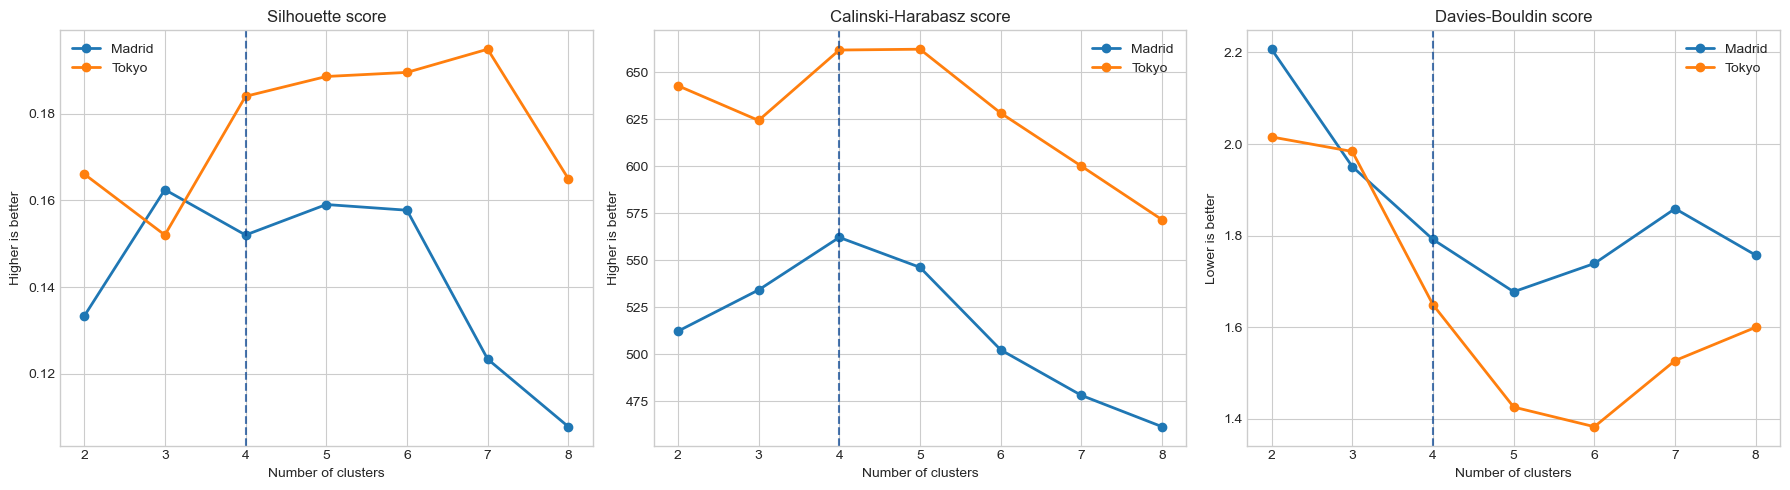

In [7]:
def plot_agglomerative_diagnostics(scores: pd.DataFrame, selected_k: int = N_CLUSTERS) -> None:
    """Plot silhouette, Calinski-Harabasz, and Davies-Bouldin scores by cluster count."""
    metrics = [
        ("silhouette_score", "Silhouette score", "Higher is better"),
        ("calinski_harabasz_score", "Calinski-Harabasz score", "Higher is better"),
        ("davies_bouldin_score", "Davies-Bouldin score", "Lower is better"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (metric, title, note) in zip(axes, metrics):
        for city, city_scores in scores.groupby("city"):
            ax.plot(city_scores["n_clusters"], city_scores[metric], marker="o", linewidth=2, label=city)

        ax.axvline(selected_k, color="#003f8f", linestyle="--", alpha=0.7)
        ax.set_title(title)
        ax.set_xlabel("Number of clusters")
        ax.set_ylabel(note)
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_agglomerative_diagnostics(scores_df)

The dashed line marks the selected 4-cluster solution. We use four clusters mainly for comparability with K-means and Gaussian Mixture rather than because it is mathematically perfect.

## 9. Dendrogram View

A dendrogram shows the hierarchy of merges. To keep it readable, this plot uses a smaller sample and truncates the tree.

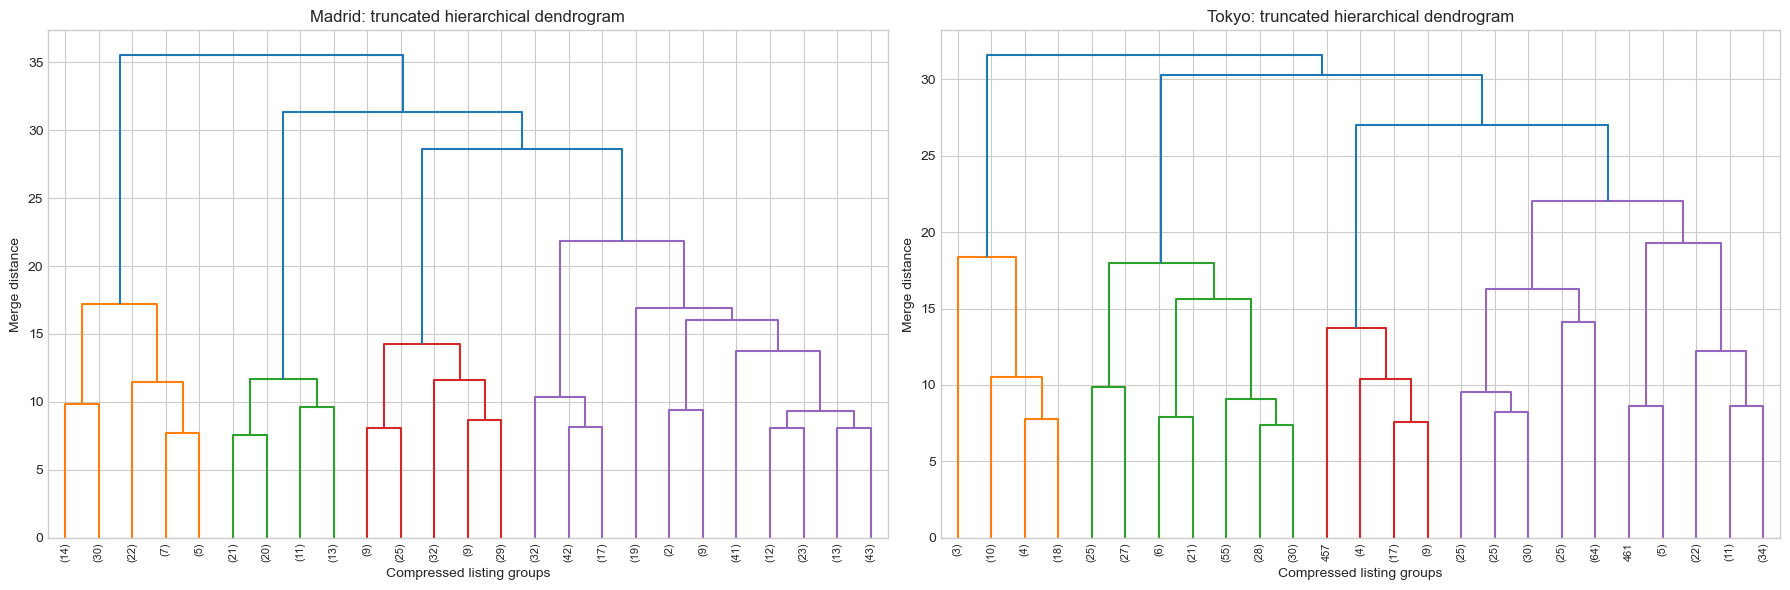

In [8]:
def plot_city_dendrograms(prepared_data: dict, sample_size: int = 500, random_state: int = RANDOM_STATE) -> None:
    """Plot truncated Ward-linkage dendrograms for each city."""
    if not SCIPY_AVAILABLE:
        print("SciPy is not available, so dendrograms cannot be plotted in this environment.")
        return

    fig, axes = plt.subplots(1, len(prepared_data), figsize=(18, 6))
    if len(prepared_data) == 1:
        axes = [axes]

    for ax, (city, info) in zip(axes, prepared_data.items()):
        sample_index = make_representative_sample(info["X_scaled"], sample_size, random_state)
        X_sample = info["X_scaled"][sample_index]
        linkage_matrix = linkage(X_sample, method="ward", metric="euclidean")

        dendrogram(
            linkage_matrix,
            truncate_mode="lastp",
            p=25,
            leaf_rotation=90,
            leaf_font_size=8,
            ax=ax,
        )
        ax.set_title(f"{city}: truncated hierarchical dendrogram")
        ax.set_xlabel("Compressed listing groups")
        ax.set_ylabel("Merge distance")

    plt.tight_layout()
    plt.show()

plot_city_dendrograms(prepared)

The vertical merge distance shows how far apart groups were when they merged. Larger jumps can suggest natural separation points, although Airbnb listings often overlap rather than forming perfectly distinct groups.

## 10. Fit the Final Agglomerative Model and Assign All Listings

Because Agglomerative Clustering cannot directly predict labels for new rows, this notebook:

1. fits the 4-cluster hierarchy on a representative city sample;
2. calculates the standardised centre of each learned cluster;
3. assigns every listing in the city dataset to the nearest learned centre using Euclidean distance.

This gives us full-city cluster profiles while keeping the notebook runnable.

In [9]:
def fit_agglomerative_and_assign_full_city(
    city: str,
    clean_df: pd.DataFrame,
    X_scaled: np.ndarray,
    n_clusters: int = N_CLUSTERS,
    sample_size: int = FINAL_SAMPLE_SIZE,
    random_state: int = RANDOM_STATE,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Fit Agglomerative Clustering on a sample and assign all rows to nearest sample cluster centre."""
    sample_index = make_representative_sample(X_scaled, sample_size, random_state)
    X_sample = X_scaled[sample_index]

    model = build_agglomerative_model(n_clusters)
    sample_labels = model.fit_predict(X_sample)

    centroids = np.vstack([X_sample[sample_labels == cluster_id].mean(axis=0) for cluster_id in range(n_clusters)])
    full_labels, distances = pairwise_distances_argmin_min(X_scaled, centroids, metric="euclidean")

    segmented = clean_df.copy().reset_index(drop=True)
    segmented["city"] = city
    segmented["agglomerative_cluster"] = full_labels
    segmented["assignment_distance_to_centroid"] = distances
    segmented["assignment_method"] = "nearest_centroid_from_agglomerative_sample"

    fit_summary = pd.DataFrame(
        [
            {
                "city": city,
                "n_clusters": n_clusters,
                "sample_rows_used_for_hierarchy": len(sample_index),
                "full_rows_assigned": len(segmented),
                "sample_silhouette_score": silhouette_score(X_sample, sample_labels),
                "mean_assignment_distance_to_centroid": float(distances.mean()),
                "median_assignment_distance_to_centroid": float(np.median(distances)),
            }
        ]
    )

    return segmented, fit_summary

segmented_frames = []
final_fit_summaries = []

for city, info in prepared.items():
    segmented_city, fit_summary = fit_agglomerative_and_assign_full_city(city, info["clean_df"], info["X_scaled"])
    segmented_frames.append(segmented_city)
    final_fit_summaries.append(fit_summary)

agglomerative_segments = pd.concat(segmented_frames, ignore_index=True)
final_fit_summary = pd.concat(final_fit_summaries, ignore_index=True)

display(
    final_fit_summary.style.format(
        {
            "sample_silhouette_score": "{:.3f}",
            "mean_assignment_distance_to_centroid": "{:.3f}",
            "median_assignment_distance_to_centroid": "{:.3f}",
        }
    )
)

,city,n_clusters,sample_rows_used_for_hierarchy,full_rows_assigned,sample_silhouette_score,mean_assignment_distance_to_centroid,median_assignment_distance_to_centroid
0,Madrid,4,5000,14446,0.159,2.297,2.145
1,Tokyo,4,5000,19158,0.206,2.133,1.988


The `assignment_distance_to_centroid` column is a practical confidence signal. Smaller values mean the listing is closer to the learned centre of its assigned segment.

## 11. Profile and Label the Clusters

The model produces numeric cluster IDs. The next step profiles those IDs and labels them from lowest to highest median price.

In [10]:
def build_cluster_profiles(segments: pd.DataFrame) -> pd.DataFrame:
    """Summarise each city-cluster using interpretable Airbnb attributes."""
    profiles = (
        segments
        .groupby(["city", "agglomerative_cluster"])
        .agg(
            listings=("price_eur", "size"),
            median_price_eur=("price_eur", "median"),
            mean_price_eur=("price_eur", "mean"),
            median_accommodates=("accommodates", "median"),
            median_bedrooms=("bedrooms", "median"),
            median_amenities=("amenities_count", "median"),
            median_distance_to_center_km=("distance_to_center_km", "median"),
            median_availability_365=("availability_365", "median"),
            mean_review_score=("review_scores_rating", "mean"),
            superhost_rate=("host_is_superhost", "mean"),
            median_minimum_nights=("minimum_nights_capped", "median"),
            mean_assignment_distance_to_centroid=("assignment_distance_to_centroid", "mean"),
        )
        .reset_index()
    )

    segment_names = ["Value", "Standard", "Premium", "Luxury"]
    labelled_frames = []

    for city, city_profiles in profiles.groupby("city"):
        ordered = city_profiles.sort_values("median_price_eur").copy()
        ordered["segment"] = segment_names[: len(ordered)]
        labelled_frames.append(ordered)

    labelled_profiles = pd.concat(labelled_frames, ignore_index=True)
    return labelled_profiles[
        [
            "city", "segment", "agglomerative_cluster", "listings", "median_price_eur", "mean_price_eur",
            "median_accommodates", "median_bedrooms", "median_amenities", "median_distance_to_center_km",
            "median_availability_365", "mean_review_score", "superhost_rate", "median_minimum_nights",
            "mean_assignment_distance_to_centroid",
        ]
    ]

cluster_profiles = build_cluster_profiles(agglomerative_segments)

segment_lookup = cluster_profiles.set_index(["city", "agglomerative_cluster"])["segment"].to_dict()
agglomerative_segments["segment"] = agglomerative_segments.apply(
    lambda row: segment_lookup[(row["city"], row["agglomerative_cluster"])], axis=1
)

display(
    cluster_profiles.style.format(
        {
            "median_price_eur": "EUR {:.2f}",
            "mean_price_eur": "EUR {:.2f}",
            "median_distance_to_center_km": "{:.2f}",
            "mean_review_score": "{:.2f}",
            "superhost_rate": "{:.1%}",
            "mean_assignment_distance_to_centroid": "{:.3f}",
        }
    )
)

,city,segment,agglomerative_cluster,listings,median_price_eur,mean_price_eur,median_accommodates,median_bedrooms,median_amenities,median_distance_to_center_km,median_availability_365,mean_review_score,superhost_rate,median_minimum_nights,mean_assignment_distance_to_centroid
0,Madrid,Value,0,1732,EUR 87.00,EUR 98.91,2.000000,1.000000,28.000000,2.03,238.500000,4.54,24.8%,30.000000,2.712
1,Madrid,Standard,1,6604,EUR 93.00,EUR 94.75,2.000000,1.000000,26.000000,2.03,239.000000,4.54,0.0%,1.000000,2.172
2,Madrid,Premium,2,3547,EUR 104.00,EUR 108.77,2.000000,1.000000,34.000000,2.05,174.000000,4.85,99.3%,2.000000,2.205
3,Madrid,Luxury,3,2563,EUR 186.00,EUR 190.48,6.000000,2.000000,31.000000,1.20,265.000000,4.61,15.5%,1.000000,2.465
4,Tokyo,Value,2,1355,EUR 67.77,EUR 80.09,3.000000,1.000000,30.000000,6.54,161.000000,4.68,26.0%,30.000000,2.304
5,Tokyo,Standard,1,8060,EUR 83.83,EUR 93.56,3.000000,1.000000,30.000000,6.47,147.000000,4.61,0.7%,1.000000,1.993
6,Tokyo,Premium,0,7286,EUR 100.52,EUR 109.84,4.000000,1.000000,34.000000,6.69,164.500000,4.85,99.4%,2.000000,2.059
7,Tokyo,Luxury,3,2457,EUR 183.74,EUR 182.65,9.000000,3.000000,38.000000,7.78,209.000000,4.82,53.0%,2.000000,2.712


The segment names are descriptive labels rather than classes known in advance. The model finds groups first; then we label them by their median nightly price to make the results easier to explain.

## 12. Visualise the Final Segments with PCA

PCA compresses the nine standardised features into two visual dimensions. This does not drive the clustering; it is only used to plot the final groups.

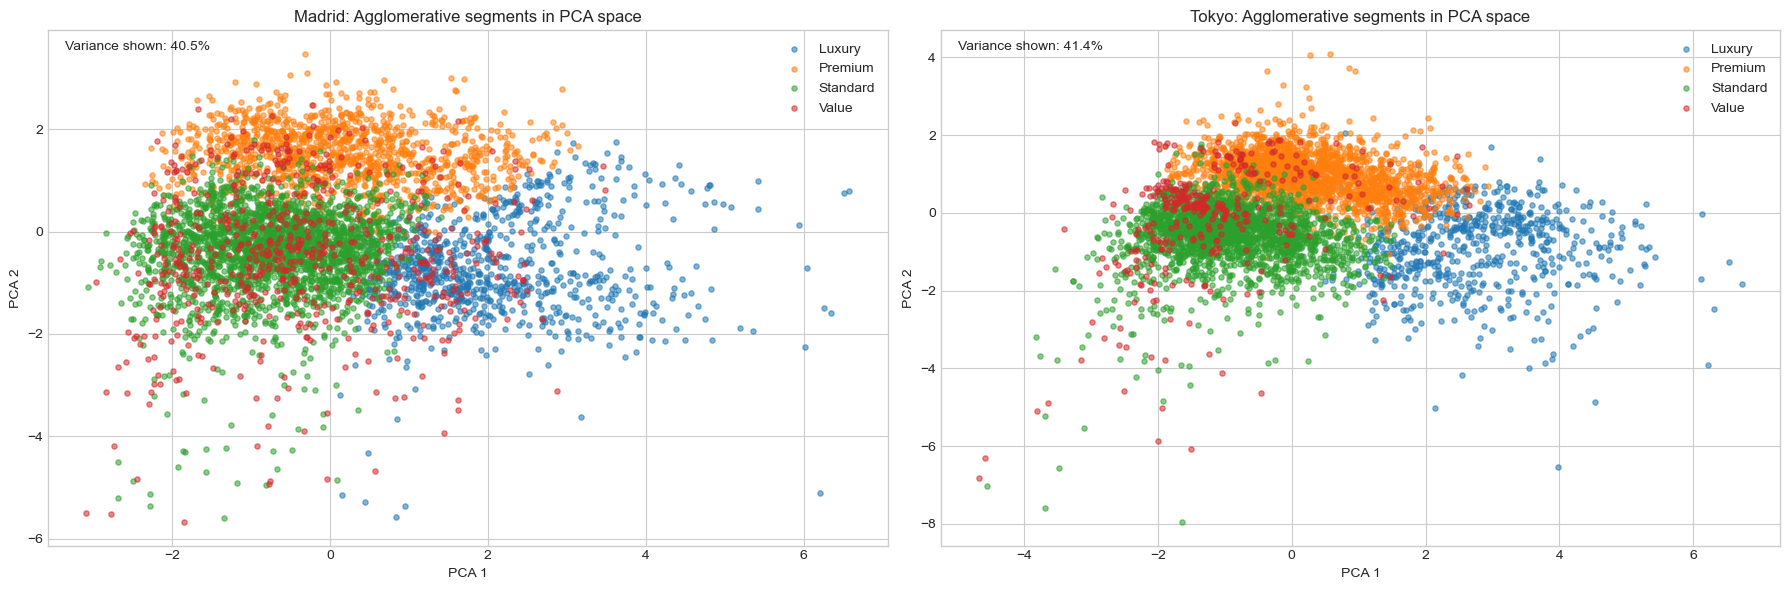

In [11]:
def plot_pca_segments(prepared_data: dict, segments: pd.DataFrame, sample_size: int = 5000, random_state: int = RANDOM_STATE) -> None:
    """Plot the assigned Agglomerative segments in two PCA dimensions."""
    fig, axes = plt.subplots(1, len(prepared_data), figsize=(18, 6))
    if len(prepared_data) == 1:
        axes = [axes]

    for ax, (city, info) in zip(axes, prepared_data.items()):
        city_segments = segments[segments["city"] == city].reset_index(drop=True)
        sample_index = make_representative_sample(info["X_scaled"], sample_size, random_state)

        X_sample = info["X_scaled"][sample_index]
        sample_segments = city_segments.iloc[sample_index].reset_index(drop=True)

        pca = PCA(n_components=2, random_state=random_state)
        coords = pca.fit_transform(X_sample)
        plot_df = pd.DataFrame(coords, columns=["pca_1", "pca_2"])
        plot_df["segment"] = sample_segments["segment"].values

        for segment, segment_rows in plot_df.groupby("segment"):
            ax.scatter(segment_rows["pca_1"], segment_rows["pca_2"], s=14, alpha=0.55, label=segment)

        explained = pca.explained_variance_ratio_.sum() * 100
        ax.set_title(f"{city}: Agglomerative segments in PCA space")
        ax.set_xlabel("PCA 1")
        ax.set_ylabel("PCA 2")
        ax.text(0.02, 0.98, f"Variance shown: {explained:.1f}%", transform=ax.transAxes, va="top")
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_pca_segments(prepared, agglomerative_segments)

If clusters overlap in the PCA plot, that is not necessarily an error. It usually means the listings form gradual market segments rather than perfectly separate groups.

## 13. Save the Agglomerative Clustering Outputs

The outputs are saved beside the existing K-means and Gaussian Mixture files.

In [12]:
def save_agglomerative_outputs(scores: pd.DataFrame, profiles: pd.DataFrame, segments: pd.DataFrame, output_dir: Path) -> dict[str, Path]:
    """Save diagnostic scores, cluster profiles, and listing-level segment assignments."""
    output_dir.mkdir(parents=True, exist_ok=True)

    scores_path = output_dir / "agglomerative_scores.csv"
    profiles_path = output_dir / "agglomerative_cluster_profiles.csv"
    segments_path = output_dir / "agglomerative_listing_segments.csv"

    scores.to_csv(scores_path, index=False)
    profiles.to_csv(profiles_path, index=False)

    segment_columns = [
        "city",
        "id" if "id" in segments.columns else None,
        "neighbourhood_cleansed" if "neighbourhood_cleansed" in segments.columns else None,
        "room_type" if "room_type" in segments.columns else None,
        "property_group" if "property_group" in segments.columns else None,
        "segment",
        "agglomerative_cluster",
        "assignment_distance_to_centroid",
        "assignment_method",
        *CLUSTER_FEATURES,
    ]
    segment_columns = [column for column in segment_columns if column is not None and column in segments.columns]
    segments[segment_columns].to_csv(segments_path, index=False)

    return {"scores": scores_path, "profiles": profiles_path, "segments": segments_path}

saved_paths = save_agglomerative_outputs(scores_df, cluster_profiles, agglomerative_segments, CLUSTER_OUTPUT_DIR)

for name, output_path in saved_paths.items():
    print(f"{name}: {output_path}")

scores: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\clustering\agglomerative_scores.csv
profiles: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\clustering\agglomerative_cluster_profiles.csv
segments: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models\clustering\agglomerative_listing_segments.csv


These files can be used later for comparison against K-means, Gaussian Mixture, and the upcoming classification notebook.

## 14. Final 4-Cluster Summary

This final view pulls together the selected 4-cluster diagnostic scores and the labelled segment profiles.

In [13]:
selected_scores = scores_df[scores_df["n_clusters"] == N_CLUSTERS].copy()

display(
    selected_scores[
        [
            "city", "n_clusters", "linkage", "distance_metric", "silhouette_score",
            "calinski_harabasz_score", "davies_bouldin_score", "sample_rows", "total_rows_available",
        ]
    ].style.format(
        {
            "silhouette_score": "{:.3f}",
            "calinski_harabasz_score": "{:.1f}",
            "davies_bouldin_score": "{:.3f}",
        }
    )
)

display(
    cluster_profiles[
        [
            "city", "segment", "listings", "median_price_eur", "median_accommodates", "median_bedrooms",
            "median_amenities", "median_distance_to_center_km", "mean_review_score", "median_availability_365",
        ]
    ].style.format(
        {
            "median_price_eur": "EUR {:.2f}",
            "median_distance_to_center_km": "{:.2f}",
            "mean_review_score": "{:.2f}",
        }
    )
)

,city,n_clusters,linkage,distance_metric,silhouette_score,calinski_harabasz_score,davies_bouldin_score,sample_rows,total_rows_available
2,Madrid,4,ward,euclidean,0.152,562.1,1.792,4000,14446
9,Tokyo,4,ward,euclidean,0.184,661.8,1.649,4000,19158


,city,segment,listings,median_price_eur,median_accommodates,median_bedrooms,median_amenities,median_distance_to_center_km,mean_review_score,median_availability_365
0,Madrid,Value,1732,EUR 87.00,2.000000,1.000000,28.000000,2.03,4.54,238.500000
1,Madrid,Standard,6604,EUR 93.00,2.000000,1.000000,26.000000,2.03,4.54,239.000000
2,Madrid,Premium,3547,EUR 104.00,2.000000,1.000000,34.000000,2.05,4.85,174.000000
3,Madrid,Luxury,2563,EUR 186.00,6.000000,2.000000,31.000000,1.20,4.61,265.000000
4,Tokyo,Value,1355,EUR 67.77,3.000000,1.000000,30.000000,6.54,4.68,161.000000
5,Tokyo,Standard,8060,EUR 83.83,3.000000,1.000000,30.000000,6.47,4.61,147.000000
6,Tokyo,Premium,7286,EUR 100.52,4.000000,1.000000,34.000000,6.69,4.85,164.500000
7,Tokyo,Luxury,2457,EUR 183.74,9.000000,3.000000,38.000000,7.78,4.82,209.000000


## 15. Key Takeaways

Agglomerative Clustering gives us a different unsupervised view from K-means and Gaussian Mixture:

- it builds groups by progressively merging similar listings;
- it uses Euclidean distance on the same standardised nine attributes;
- it is useful for explaining how listing groups relate hierarchically;
- the dendrogram gives an intuitive visual of the cluster-building process;
- because the Airbnb market is continuous, we should expect moderate rather than perfect separation.